<div style="display: flex; align-items: center; width: 100%;">  
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">    
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>  
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Cross-Validation &amp; Backtest Overfitting
    </h1>
  </div>  
</div>

In finance, labels overlap in time, so a naive train/test split **leaks** future
information into training and inflates measured performance. The cures:

- **Purged K-Fold** removes training samples that overlap the test set (plus an
  **embargo** after it),
- **Combinatorial Purged CV (CPCV)** builds *many* backtest paths instead of one,
- **Probability of Backtest Overfitting (PBO)** quantifies how likely your
  in-sample-best strategy is to disappoint out-of-sample.

References: López de Prado, *Advances in Financial Machine Learning*, Ch. 7, 11–12.

## 1. A labeled dataset with overlapping information

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))   # the pinned notebook environment

using RiskLabAI
using Random, Statistics, DataFrames, Plots
gr()
theme(:default)                                   # theme-adaptive figures (legible on GitHub light & dark)
default(background_color = :transparent, background_color_inside = :transparent,
        foreground_color = "#888888", gridalpha = 0.3,
        legend_background_color = :transparent)

  Activating project at `C:\arian\risklabai\Notebooks.jl`


In [2]:
x, y, feature_names = get_test_dataset(; n_features = 10, n_informative = 4,
    n_redundant = 2, n_samples = 400, random_state = 1)

# Each label's information spans ~5 steps, so neighbouring samples overlap in
# time — exactly what purging must remove.
n = size(x, 1)
event_starts = collect(1:n)
event_ends = min.(event_starts .+ 5, n)
println("dataset: $(n) samples × $(size(x, 2)) features")

dataset: 400 samples × 10 features


## 2. Purged K-Fold vs naive K-Fold

Purging drops overlapping training rows, so each purged fold trains on *fewer*,
cleaner samples than a naive fold.

In [3]:
purged = PurgedKFoldCV(5, event_starts, event_ends; embargo = 0.02)
naive  = KFoldCV(5)

purged_splits = cv_split(purged)
naive_splits  = cv_split(naive, n)

DataFrame(fold = 1:5,
          naive_train  = [length(tr) for (tr, _) in naive_splits],
          purged_train = [length(tr) for (tr, _) in purged_splits],
          test         = [length(te) for (_, te) in purged_splits])

Row,fold,naive_train,purged_train,test
,Int64,Int64,Int64,Int64
1,1,320,307,80
2,2,320,302,80
3,3,320,302,80
4,4,320,302,80
5,5,320,315,80


## 3. Walk-forward and Combinatorial Purged CV

Walk-forward grows the training window through time. CPCV instead recombines
test groups into **many** backtest paths — a far more robust estimate of
out-of-sample performance than a single split.

In [4]:
wf = WalkForwardCV(5)
wf_splits = cv_split(wf, n)
println("walk-forward train sizes (growing): ", [length(tr) for (tr, _) in wf_splits])

cpcv = CombinatorialPurgedCV(6, 2, event_starts, event_ends; embargo = 0.02)
println("CPCV: $(get_n_splits(cpcv)) train/test splits → ",
        "$(length(backtest_paths(cpcv))) backtest paths")

walk-forward train sizes (growing): 

[0, 80, 160, 240, 320]


CPCV: 15 train/test splits → 5 backtest paths


## 4. Scoring a model honestly

A random forest scored under purged CV reports a more honest accuracy than under
naive CV (which is optimistically biased by leakage). We can also tune
hyper-parameters *through* the purged validator.

In [5]:
naive_acc  = cross_val_score(naive,  x, y; n_trees = 50, random_state = 1)
purged_acc = cross_val_score(purged, x, y; n_trees = 50, random_state = 1)
println("CV accuracy — naive: $(round(mean(naive_acc); digits = 3))   ",
        "purged: $(round(mean(purged_acc); digits = 3))")

grid = Dict(:n_trees => [20, 50], :max_depth => [3, 6])
gs = grid_search_cv(purged, x, y, grid; random_state = 1)
println("grid-search best: ", gs.best_params, "  (CV score $(round(gs.best_score; digits = 3)))")

CV accuracy — naive: 0.98   purged: 0.97


grid-search best: Dict{Symbol, Any}(:

n_trees => 50, :max_depth => 6)  (CV score 0.97)


## 5. Probability of Backtest Overfitting (PBO)

Suppose we try many strategy configurations and keep the in-sample best. PBO
estimates the probability the in-sample winner ranks below median out-of-sample,
a direct measure of overfitting risk. We feed it 50 skill-less (pure-noise)
strategies; the logit histogram shows where that winner lands out-of-sample.

PBO across 50 skill-less strategies: 0.202


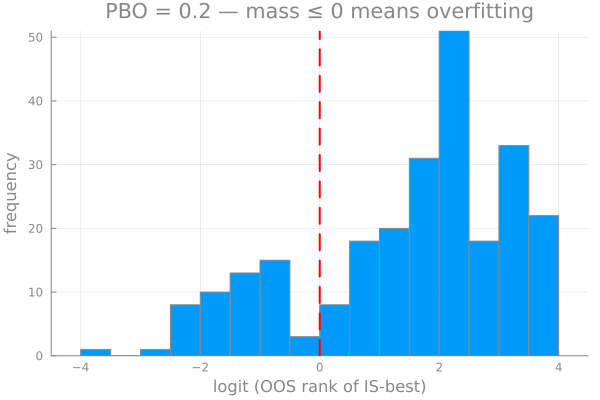

In [6]:
rng = MersenneTwister(1)
T, N = 1000, 50
noise = randn(rng, T, N)                 # 50 skill-less return streams
metric = (r, rf) -> sharpe_ratio(r; risk_free_rate = rf)

pbo, logits = probability_of_backtest_overfitting(noise; n_partitions = 10, metric = metric)
println("PBO across $(N) skill-less strategies: ", round(pbo; digits = 3))

histogram(logits; bins = 20, legend = false, xlabel = "logit (OOS rank of IS-best)",
          ylabel = "frequency",
          title = "PBO = $(round(pbo; digits = 2)) — mass ≤ 0 means overfitting")
vline!([0.0]; c = :red, ls = :dash, lw = 2)

## Takeaways

- Purging and embargo avoid leakage; purged folds train on fewer, cleaner samples.
- CPCV turns one fragile backtest into many paths.
- PBO puts a number on overfitting risk: an in-sample winner may not persist.
